
## ISO BIMODAL ANALYSIS SUITE (MJO & BSISO) 

MJO(Madden-Julian Oscillation) and BSISO(Boreal Summer Intraseasonal Oscillation)

Authors: orginal NCL script is done by Eun-Pa Lim; now convert to Python by Arnold Sullivan

History: 03072026

mjoclivar_16.ncl: Create composite life cycles. This example uses 20-100 day band passed filtered anomaly OLR, U850, V850 for the years 1995-1999. The netCF file created in Example 14, which contains the PC1 and PC2, is used to derive the appropriate MJO phase category. The size of the reference anomaly wind vector is in the upper right. The phase (eg P3, means "Phase 3") and the number of days used to create the composite are at the lower right.
This script was updated 29 July 2016. (Source: Eun-Pa Lim, Bureau of Meteorology, Australia)


#### FUNCTION REFERENCE:
* lanczos_bandpass_filter: Isolates the 25–90-day signal with a 139-tap 
  Hamming-window FIR filter. Corrects for phase lag and trims both edges.
* calculate_eeof: Constructs the lagged data matrix (EEOF), performs area-
  weighted PCA, and normalises PCs to unit variance.
* project_entire_year: A "Projector" function that takes year-round data and 
  maps it onto fixed seasonal "fingerprints" to calculate daily ISO amplitude.
* plot_phase_space: Generates the 8-phase wheel with geographical annotations 
  specific to MJO (equatorial) vs BSISO (off-equator) propagation.

DATA AND ENVIRONMENT:
The example uses ACCESS-ESM1-5 piControl daily `rlut` covering 0296–0325. It was run with the Gadi analysis3-26.08 environment. Outputs are cleared in source control so the notebook runs from a fresh kernel.

REFERENCES:

1. The Original Bimodal Index Paper (2012)
This paper introduced the original EEOF-based index using 3-month solstice seasons (DJF and JJA) to define the MJO and BSISO modes.
   - **APA:** Kikuchi, K., Wang, B., & Kajikawa, Y. (2012). Bimodal representation of the tropical intraseasonal oscillation. *Climate Dynamics*, *38*, 1989-2000.
   - **DOI:** 10.1007/s00382-011-1159-1

2. The JRA-55 Extension & Revision Paper (2020)
This study extended the index back to 1958 using reanalysis data and updated the methodology to use **extended seasons** (December-April and June-October) for the EEOF analysis.
   - **APA:** Kikuchi, K. (2020). Extension of the bimodal intraseasonal oscillation index using JRA-55 reanalysis. *Climate Dynamics*, *54*, 919-933.
   - **Key Update:** This paper justifies the switch from 3-month to 5-month seasons to represent the ISO more faithfully throughout the year.

3. The BSISO Review Paper (2021)
This comprehensive review summarizes the fundamental features, theories, and simulation status of the BSISO, using the bimodal index as a consistent baseline for analysis.
   - **APA:** Kikuchi, K. (2021). The boreal summer intraseasonal oscillation: A review. *Journal of the Meteorological Society of Japan*, *99*(4), 933-972.
   - **DOI:** 10.2151/jmsj.2021-045

In [1]:
# import dask.distributed as dask

# client = dask.Client(threads_per_worker = 1)
# client

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.decomposition import PCA
from scipy.signal import firwin, lfilter

from esmvalcore.dataset import Dataset
from esmvalcore.preprocessor import (
    extract_region, 
    extract_season,
    anomalies,
)

## Find data

In [3]:
mod = Dataset(
    short_name='rlut', project='CMIP6', activity='*',
    mip="day", exp="piControl", ensemble="r1i1p1f1",
    timerange="0295/0326", dataset="ACCESS-ESM1-5", grid="gn"
)
# mod.files

In [4]:
#
def lanczos_bandpass_filter(cube_anom, low=25, high=90, window=139):
    """Apply a 25–90-day FIR band-pass and discard both contaminated edges."""
    da = xr.DataArray.from_iris(cube_anom)
    rename = {long: short for long, short in (("latitude", "lat"), ("longitude", "lon")) if long in da.dims}
    da = da.rename(rename).chunk(dict(time=-1))
    
    f_high, f_low = 1.0/low, 1.0/high
    weights = firwin(window, [f_low, f_high], pass_zero=False, fs=1.0)
    def apply_fir(x): return lfilter(weights, 1, x, axis=0)
    filtered = xr.apply_ufunc(apply_fir, da, input_core_dims=[["time"]],
                              output_core_dims=[["time"]], vectorize=True, dask="parallelized")
    return filtered.shift(time=-(window // 2)).isel(time=slice(window // 2, -(window // 2)))

In [5]:
# 1. Spatial Subset and Anomalies
rlut = mod.load()
rlut = extract_region(rlut, start_longitude=-180, end_longitude=180, start_latitude=-30, end_latitude=30)

rlut_anom = anomalies(rlut, period="daily")
rlut_filtered = lanczos_bandpass_filter(rlut_anom).dropna("time")

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/esmvalcore/config/_config.py:49: ESMValCoreDeprecationWarning: Usage of extra facets located in ~/.esmvaltool/extra_facets has been deprecated in ESMValCore version 2.13.0 and is scheduled for removal in version 2.15.0. Please use the configuration option `extra_facets` instead (see https://github.com/ESMValGroup/ESMValCore/pull/2747 for details). To silent this warning and ignore deprecated extra facets, set the environment variable ESMVALTOOL_USE_NEW_EXTRA_FACETS_CONFIG=1.
  warn_if_old_extra_facets_exist()
 rlut: attribute positive not present
loaded from file 
/jobfs/180164058.gadi-pbs/ipykernel_758638/1052898984.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  da = xr.DataArray.from_iris(cube_anom)
/jobfs/1801

In [6]:
# xr.DataArray.from_iris(rlut_anom).chunk(dict(time=-1))
rlut_filtered

<xarray.DataArray 'rlut' (lat: 49, lon: 192, time: 10819)> Size: 814MB
dask.array<getitem, shape=(49, 192, 10819), dtype=float64, chunksize=(49, 96, 10819), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 392B -30.0 -28.75 -27.5 -26.25 ... 27.5 28.75 30.0
  * lon      (lon) float64 2kB -180.0 -178.1 -176.2 -174.4 ... 174.4 176.2 178.1
  * time     (time) object 87kB 0296-03-10 12:00:00 ... 0325-10-23 12:00:00
Attributes: (12/52)
    standard_name:          toa_outgoing_longwave_flux
    long_name:              TOA Outgoing Longwave Radiation
    units:                  W m-2
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    version:                v20191202
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/3f6bae96-38c6-4866-b9c9-23bbe3bcbf8c
    license:                CMIP6 model data produced by CSIRO is licensed un...
    comment:                at the top of the atmosphere (to be compared with...
    cell_methods:           area: time: mean

In [7]:
def calculate_eeof(da_full, lat_name, lon_name, months, lags=[-10, -5, 0]):
    """Fit seasonal EEOFs using lags from the continuous daily series."""
    times = da_full.time.values
    if any((right - left) != np.timedelta64(1, "D") for left, right in zip(times[:-1], times[1:])):
        raise ValueError("EEOF lags require a continuous daily time axis")
    lagged_list = []
    for lag in lags:
        shifted = da_full.shift(time=-lag)
        shifted = shifted.expand_dims(lag=[lag])
        lagged_list.append(shifted)
    
    extended_da = xr.concat(lagged_list, dim='lag').dropna('time', how='any')
    extended_da = extended_da.sel(time=extended_da.time.dt.month.isin(months))
    
    # Area-weighting by sqrt(cos(lat))
    weights = np.sqrt(np.cos(np.deg2rad(extended_da[lat_name])))
    weighted_da = extended_da * weights
    
    n_lag, n_lat, n_lon = len(lags), len(da_full[lat_name]), len(da_full[lon_name])
    n_time = len(extended_da.time)
    
    # Flattening for PCA
    matrix = weighted_da.transpose('time', 'lag', lat_name, lon_name).values.reshape(n_time, -1)
    
    pca = PCA(n_components=2)
    pcs_raw = pca.fit_transform(matrix) 
    var_exp = pca.explained_variance_ratio_ * 100
    
    # Unit Variance Normalization
    pc_std = pcs_raw.std(axis=0)
    pcs_normalized = pcs_raw / pc_std
    eeofs_scaled = pca.components_ * pc_std[:, np.newaxis]
    
    # Reconstruct into Xarray
    eeof_da = xr.DataArray(
        eeofs_scaled.reshape(2, n_lag, n_lat, n_lon),
        coords={'mode': [0, 1], 'lag': lags, lat_name: da_full[lat_name].values, lon_name: da_full[lon_name].values},
        dims=['mode', 'lag', lat_name, lon_name]
    )
    
    pc_da = xr.DataArray(
        pcs_normalized,
        coords={'time': extended_da.time.values, 'mode': [1, 2]},
        dims=['time', 'mode']
    )
    return eeof_da, pc_da, var_exp, pca.mean_, pc_std

In [8]:
# 2. Seasonal Selection & EEOF Calculation
lags = [-10, -5, 0]
eeof_mjo, pc_mjo, var_mjo, mean_mjo, std_mjo = calculate_eeof(rlut_filtered, 'lat', 'lon', [12, 1, 2], lags=lags)
eeof_bsiso, pc_bsiso, var_bsiso, mean_bsiso, std_bsiso = calculate_eeof(rlut_filtered, 'lat', 'lon', [6, 7, 8], lags=lags)

In [9]:
# Apply the BSISO PC2/EEOF2 sign convention once, as a pair.
# The absolute geographic phase labels still require comparison with a published reference.
eeof_bsiso.loc[dict(mode=1)] *= -1
pc_bsiso.loc[dict(mode=2)] *= -1


In [10]:
# ======================================================

def project_entire_year(da_full, eeof_da, pca_mean, pc_std, lags=[-10, -5, 0]):
    """
    Projects the full year of data onto the fixed seasonal EEOF patterns.
    """
    # Create lagged fields for the entire dataset
    lagged_list = []
    for lag in lags:
        shifted = da_full.shift(time=-lag)
        shifted = shifted.expand_dims(lag=[lag])
        lagged_list.append(shifted)
    
    extended_full = xr.concat(lagged_list, dim='lag').dropna('time', how='any')
    
    # Apply area-weighting (consistent with EEOF)
    weights = np.sqrt(np.cos(np.deg2rad(extended_full['lat'])))
    weighted_full = extended_full * weights
    
    # Prepare data matrix (Time x Flattened Space-Lag)
    n_time = len(extended_full.time)
    matrix_full = weighted_full.transpose('time', 'lag', 'lat', 'lon').values.reshape(n_time, -1)
    
    # Flatten EEOF patterns (Mode x Flattened Space-Lag)
    flat_eeofs = eeof_da.values.reshape(2, -1)
    
    # Project: dot product (Data @ Patterns.T)
    # This gives us the raw PC scores for every day
    pcs_projected = np.dot(matrix_full - pca_mean, flat_eeofs.T) / (pc_std ** 2)
    
    # Normalize to unit variance (standard practice for Amplitude thresholds)
    pcs_final = pcs_projected
    
    return xr.DataArray(
        pcs_final,
        coords={'time': extended_full.time.values, 'mode': [1, 2]},
        dims=['time', 'mode']
    )


In [11]:
# --- Execute Projection for the Whole Dataset ---
pc_mjo_all = project_entire_year(rlut_filtered, eeof_mjo, mean_mjo, std_mjo, lags=lags)

In [12]:
pc_bsiso_all = project_entire_year(rlut_filtered, eeof_bsiso, mean_bsiso, std_bsiso, lags=lags)

### Add composite life cycles figure

In [13]:
def calculate_lifecycle_composite(cube_anom, pc_da, amplitude_threshold=1.0, seasons=None):
    """Calculates life cycle composites based upon daily phase space (Phase 1-8)."""
    da_anom = xr.DataArray.from_iris(cube_anom)
    common_time = np.intersect1d(da_anom.time.values, pc_da.time.values)
    da_sub = da_anom.sel(time=common_time)
    pc_sub = pc_da.sel(time=common_time)
    
    pc1 = pc_sub.sel(mode=1).values
    pc2 = pc_sub.sel(mode=2).values
    
    amplitude = np.sqrt(pc1**2 + pc2**2)
    angles_deg = np.degrees(np.arctan2(pc2, pc1))
    
    # Map into Phase 1-8 based on WH-MJO phase wheel sectors
    bins = np.linspace(-180, 180, 9)
    phases = np.digitize(angles_deg, bins)
    
    df_meta = pd.DataFrame({
        'phase': phases,
        'amplitude': amplitude,
        'month': da_sub.time.dt.month.values
    }, index=da_sub.time.values)
    
    mask = df_meta['amplitude'] >= amplitude_threshold
    if seasons is not None:
        mask = mask & (df_meta['month'].isin(seasons))
        
    df_filtered = df_meta[mask]
    
    composite_list = []
    phase_counts = {}
    
    for p in range(1, 9):
        target_dates = df_filtered[df_filtered['phase'] == p].index
        phase_counts[f"Phase {p}"] = len(target_dates)
        
        if len(target_dates) > 0:
            p_mean = da_sub.sel(time=target_dates).mean(dim='time')
            p_mean = p_mean.expand_dims(phase=[p])
            composite_list.append(p_mean)
        else:
            dummy = da_sub.isel(time=0).copy(deep=True) * np.nan
            dummy = dummy.expand_dims(phase=[p])
            composite_list.append(dummy)
            
    composite_da = xr.concat(composite_list, dim='phase')
    print(f"Effective days per phase for target seasons {seasons}:", phase_counts)
    return composite_da, phase_counts

In [14]:
# 4. Calculate Lifecycle Composites (Using rlut_anom fields)
comp_mjo, counts_mjo = calculate_lifecycle_composite(rlut_anom, pc_mjo_all, amplitude_threshold=1.0, seasons=[12, 1, 2])
comp_bsiso, counts_bsiso = calculate_lifecycle_composite(rlut_anom, pc_bsiso_all, amplitude_threshold=1.0, seasons=[6, 7, 8])

/jobfs/180164058.gadi-pbs/ipykernel_758638/4173953875.py:3: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  da_anom = xr.DataArray.from_iris(cube_anom)
/jobfs/180164058.gadi-pbs/ipykernel_758638/4173953875.py:3: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  da_anom = xr.DataArray.from_iris(cube_anom)


Effective days per phase for target seasons [12, 1, 2]: {'Phase 1': 203, 'Phase 2': 199, 'Phase 3': 198, 'Phase 4': 194, 'Phase 5': 216, 'Phase 6': 206, 'Phase 7': 202, 'Phase 8': 180}


/jobfs/180164058.gadi-pbs/ipykernel_758638/4173953875.py:3: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  da_anom = xr.DataArray.from_iris(cube_anom)
/jobfs/180164058.gadi-pbs/ipykernel_758638/4173953875.py:3: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  da_anom = xr.DataArray.from_iris(cube_anom)


Effective days per phase for target seasons [6, 7, 8]: {'Phase 1': 214, 'Phase 2': 229, 'Phase 3': 194, 'Phase 4': 199, 'Phase 5': 222, 'Phase 6': 195, 'Phase 7': 172, 'Phase 8': 241}


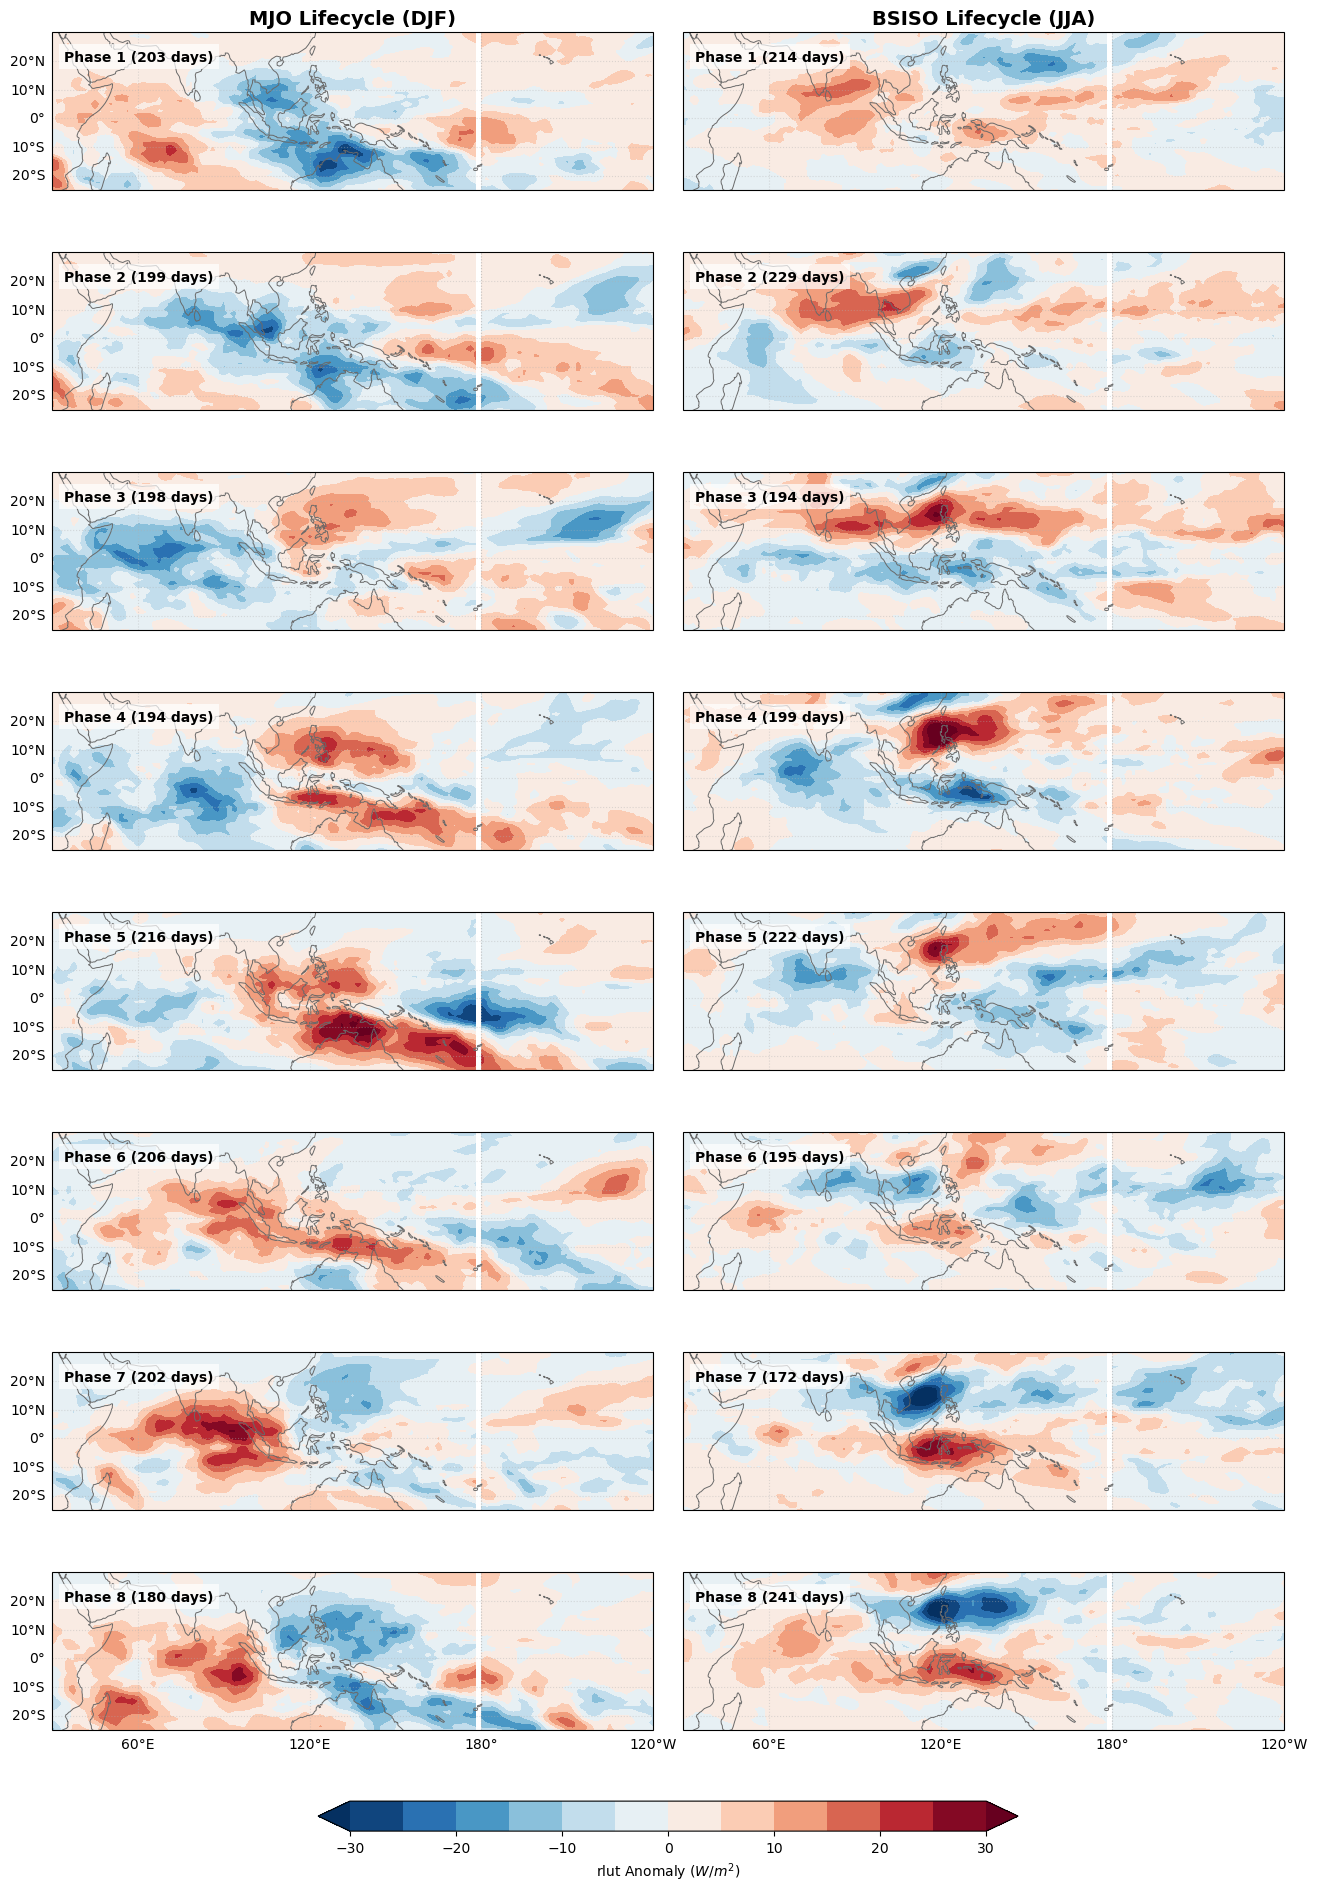

In [15]:
# --- Plotting Composites (8 Phases x 2 Modes Grid) ---
map_proj = ccrs.PlateCarree(central_longitude=180)
data_proj = ccrs.PlateCarree()

fig, axes = plt.subplots(8, 2, figsize=(14, 20), subplot_kw={'projection': map_proj})
levels = np.linspace(-30, 30, 13)
cmap = 'RdBu_r'

for phase_idx in range(8):
    phase_val = phase_idx + 1
    
    # Column 0: MJO
    ax_m = axes[phase_idx, 0]
    plot_m = comp_mjo.sel(phase=phase_val)
    cf_m = ax_m.contourf(plot_m['lon'], plot_m['lat'], plot_m.values,
                         transform=data_proj, cmap=cmap, levels=levels, extend='both')
    ax_m.coastlines(color='dimgray', linewidth=0.7)
    ax_m.set_extent([30, 240, -25, 30], crs=data_proj)
    ax_m.text(0.02, 0.82, f'Phase {phase_val} ({counts_mjo[f"Phase {phase_val}"]} days)', 
              transform=ax_m.transAxes, fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    if phase_idx == 0:
        ax_m.set_title("MJO Lifecycle (DJF)", fontsize=14, fontweight='bold')
    
    # Column 1: BSISO
    ax_b = axes[phase_idx, 1]
    plot_b = comp_bsiso.sel(phase=phase_val)
    cf_b = ax_b.contourf(plot_b['lon'], plot_b['lat'], plot_b.values,
                         transform=data_proj, cmap=cmap, levels=levels, extend='both')
    ax_b.coastlines(color='dimgray', linewidth=0.7)
    ax_b.set_extent([30, 240, -25, 30], crs=data_proj)
    ax_b.text(0.02, 0.82, f'Phase {phase_val} ({counts_bsiso[f"Phase {phase_val}"]} days)', 
              transform=ax_b.transAxes, fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    if phase_idx == 0:
        ax_b.set_title("BSISO Lifecycle (JJA)", fontsize=14, fontweight='bold')
        
    # Gridline adjustments
    for ax in [ax_m, ax_b]:
        gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.4)
        gl.top_labels = gl.right_labels = False
        if ax == ax_b: gl.left_labels = False
        if phase_idx != 7: gl.bottom_labels = False

plt.subplots_adjust(left=0.06, right=0.94, bottom=0.08, top=0.95, hspace=0.1, wspace=0.05)
cbar_ax = fig.add_axes([0.25, 0.04, 0.5, 0.015])
fig.colorbar(cf_m, cax=cbar_ax, orientation='horizontal', label='rlut Anomaly ($W/m^2$)')